# Logistic Regression

As discussed earlier, some **regression algorithms** can also be used for **classification** — and one of the most common examples is **Logistic Regression** (also called **Logit Regression**).

Logistic Regression is widely used to estimate the **probability** that an instance belongs to a particular class.

For example:
> What is the probability that this email is spam?

If the predicted probability is greater than 50%, the model predicts that the instance belongs to the **positive class** (labeled **1**).  
Otherwise, it predicts that it belongs to the **negative class** (labeled **0**).

Thus, **Logistic Regression** is a **binary classifier**.


## Estimating Probabilities

Like **Linear Regression**, a Logistic Regression model first computes a **weighted sum** of the input features (plus a bias term):

$$
z = \mathbf{x}^\top \boldsymbol{\theta}
$$

However, instead of outputting this value directly, it applies a **logistic (sigmoid)** function to squash it into a range between 0 and 1.

The estimated probability that instance \( \mathbf{x} \) belongs to the positive class is:

$$
p = h_\theta(\mathbf{x}) = \sigma(\mathbf{x}^\top \boldsymbol{\theta})
$$

where $ \sigma(\cdot) $ is the **logistic (sigmoid)** function.


## The Logistic (Sigmoid) Function

The **logistic function** is defined as:

$$
\sigma(t) = \frac{1}{1 + e^{-t}}
$$

It maps any real number $ t $ into the interval $ (0, 1) $.

The resulting S-shaped curve (sigmoid) makes it ideal for representing probabilities.


In [1]:
# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

# Common imports
import numpy as np
import os

# to make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# Where to save the figures
PROJECT_ROOT_DIR = "."
CHAPTER_ID = "training_linear_models"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)
os.makedirs(IMAGES_PATH, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

Saving figure logistic_function_plot


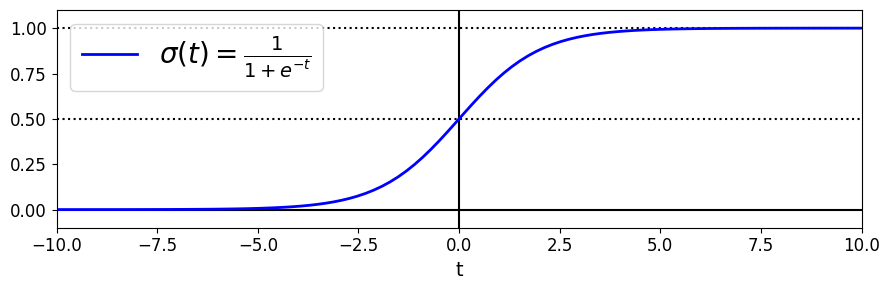

In [2]:
import numpy as np
t = np.linspace(-10, 10, 100)
sig = 1 / (1 + np.exp(-t))
plt.figure(figsize=(9, 3))
plt.plot([-10, 10], [0, 0], "k-")
plt.plot([-10, 10], [0.5, 0.5], "k:")
plt.plot([-10, 10], [1, 1], "k:")
plt.plot([0, 0], [-1.1, 1.1], "k-")
plt.plot(t, sig, "b-", linewidth=2, label=r"$\sigma(t) = \frac{1}{1 + e^{-t}}$")
plt.xlabel("t")
plt.legend(loc="upper left", fontsize=20)
plt.axis([-10, 10, -0.1, 1.1])
save_fig("logistic_function_plot")
plt.show()

## Decision Rule

Once the probability \( p \) is computed, the predicted class is obtained using a **threshold**:

$$
\hat{y} = 
\begin{cases}
1, & \text{if } p \ge 0.5 \\
0, & \text{if } p < 0.5
\end{cases}
$$

This makes Logistic Regression a **probabilistic binary classifier**.


## Logistic Regression Model Prediction

Once the Logistic Regression model has estimated the probability $p = h_\theta(x)$ that an instance $x$ belongs to the positive class, it can easily make its prediction $\hat{y}$, as shown in Equation 4-15.

### Equation 4-15 — Logistic Regression Model Prediction

$\hat{y} =
\begin{cases}
0, & \text{if } p < 0.5 \\
1, & \text{if } p \ge 0.5
\end{cases}$

---

### Interpretation

Notice that $ \sigma(t) < 0.5 $ when $ t < 0 $, and $ \sigma(t) \ge 0.5 $ when $ t \ge 0 $.  
Therefore, a Logistic Regression model predicts $1$ if $x^\top \theta$ is positive and $0$ if it is negative.

In other words, the **decision boundary** corresponds to all points where $x^\top \theta = 0$ — a straight line (or hyperplane in higher dimensions), making Logistic Regression a **linear classifier**.


## The Logit (Log-Odds)

The score $t$ computed by the Logistic Regression model is often called the **logit**.  

The name comes from the **logit function**, defined as:

$ \text{logit}(p) = \log\left(\frac{p}{1 - p}\right) $

The logit function is the **inverse** of the logistic (sigmoid) function.  
Indeed, if you compute the logit of the estimated probability $p$, you will get back the score $t$:

$ t = \text{logit}(p) $

The logit is also called the **log-odds**, since it represents the logarithm of the ratio between:

- the estimated probability for the **positive class** ($p$), and  
- the estimated probability for the **negative class** ($1 - p$):

$ \text{log-odds} = \log\left(\frac{p}{1 - p}\right) $


# Logistic Regression: Training and Cost Function

Now that we know how a Logistic Regression model estimates probabilities and makes predictions, let's see **how it is trained**.

The objective of training is to find the parameter vector $\theta$ such that:

- The model estimates **high probabilities** for positive instances ($y = 1$)
- The model estimates **low probabilities** for negative instances ($y = 0$)

This idea is captured by the **cost function for a single training instance** $x$:

### Cost Function for a Single Instance

$\displaystyle c_\theta =
\begin{cases} 
- \log p & \text{if } y = 1 \\[2mm]
- \log (1 - p) & \text{if } y = 0
\end{cases}$

---

### Intuition

- $- \log t$ grows very large as $t \to 0$.  
  - So the cost is **high** if the model predicts a **low probability** for a positive instance.  
  - Similarly, the cost is high if the model predicts a **high probability** for a negative instance.

- $- \log t$ is **close to 0** when $t \to 1$.  
  - So the cost is **low** if the predicted probability is correct (high for positive, low for negative).

This ensures that minimizing the cost encourages **accurate probability estimates**.

---

### Cost Function Over the Entire Training Set (Log Loss)

For $m$ training instances, the average cost (called **log loss**) is:

$\displaystyle J(\theta) = - \frac{1}{m} \sum_{i=1}^{m} \Big[ y_i \log p_i + (1 - y_i) \log (1 - p_i) \Big]$

---

### Key Notes

- There is **no closed-form solution** for $\theta$ that minimizes this cost function (unlike Linear Regression's Normal Equation).  
- **Good news:** The cost function is **convex**, so **Gradient Descent** (or other optimization algorithms) is guaranteed to find the global minimum, provided the learning rate is reasonable and the optimization runs long enough.

---

### Gradient (Partial Derivatives)

The partial derivative of the cost function with respect to the $j$-th parameter $\theta_j$ is:

$\displaystyle \frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{m} \sum_{i=1}^{m} \left( \sigma(\theta^\top x_i) - y_i \right) x_{i,j}$

- This is very similar to Linear Regression:  
  - For each instance, compute the **prediction error**  
  - Multiply by the **feature value** $x_{i,j}$  
  - Average over all instances

---

### Training with Gradient Descent

- Once we have the **gradient vector** containing all partial derivatives, we can use it in **Batch Gradient Descent**.  
- For **Stochastic Gradient Descent (SGD)**, use **one instance at a time**.  
- For **Mini-batch Gradient Descent**, use **a small batch of instances** at a time.  

And that’s how you train a Logistic Regression model!


# Logistic Regression: Decision Boundaries Example

We will use the **Iris dataset** to illustrate Logistic Regression.

- The Iris dataset contains **150 flowers** from three species:  
  - Iris setosa  
  - Iris versicolor  
  - Iris virginica  

- Features include **sepal length, sepal width, petal length, petal width**.  

In this example, we will build a **binary classifier** to detect **Iris virginica** using **petal width only**.  


In [3]:
# Load Iris dataset
from sklearn import datasets
import numpy as np

iris = datasets.load_iris()
list(iris.keys())


['data',
 'target',
 'frame',
 'target_names',
 'DESCR',
 'feature_names',
 'filename',
 'data_module']

In [4]:
# Select petal width as feature
X = iris["data"][:, 3:]  # petal width
y = (iris["target"] == 2).astype(np.int32)  # 1 if Iris virginica, else 0


## Train Logistic Regression Model
We train a Logistic Regression classifier using the petal width feature.


In [5]:
from sklearn.linear_model import LogisticRegression

# Initialize and fit the model
log_reg = LogisticRegression()
log_reg.fit(X, y)


LogisticRegression()

## Estimated Probabilities

We can visualize the model's **predicted probabilities** for flowers with petal widths ranging from 0 cm to 3 cm.


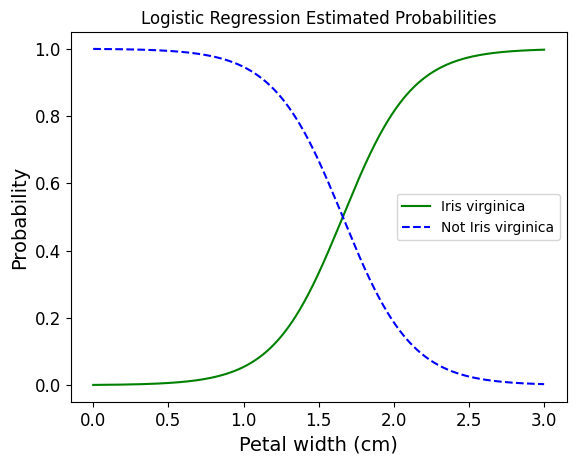

In [6]:
import matplotlib.pyplot as plt

# Generate new petal width values
X_new = np.linspace(0, 3, 1000).reshape(-1, 1)

# Predicted probabilities
y_proba = log_reg.predict_proba(X_new)

# Plot probabilities
plt.plot(X_new, y_proba[:, 1], "g-", label="Iris virginica")
plt.plot(X_new, y_proba[:, 0], "b--", label="Not Iris virginica")
plt.xlabel("Petal width (cm)")
plt.ylabel("Probability")
plt.title("Logistic Regression Estimated Probabilities")
plt.legend()
plt.show()


The petal width of Iris virginica flowers (represented by triangles) ranges from 1.4 cm
to 2.5 cm, while the other iris flowers (represented by squares) generally have a
smaller petal width, ranging from 0.1 cm to 1.8 cm. Notice that there is a bit of over‐
lap. Above about 2 cm the classifier is highly confident that the flower is an Iris virgin‐
ica (it outputs a high probability for that class), while below 1 cm it is highly
confident that it is not an Iris virginica (high probability for the “Not Iris virginica”

class). In between these extremes, the classifier is unsure. However, if you ask it to
predict the class (using the predict() method rather than the predict_proba()
method), it will return whichever class is the most likely. Therefore, there is a decision
boundary at around 1.6 cm where both probabilities are equal to 50%: if the petal
width is higher than 1.6 cm, the classifier will predict that the flower is an Iris virgin‐
ica, and otherwise it will predict that it is not (even if it is not very confident):

In [12]:
log_reg.predict([[1.7], [1.5],[1.68]])

array([1, 0, 1], dtype=int32)

# Softmax Regression (Multinomial Logistic Regression)

Softmax Regression generalizes **Logistic Regression** to support **multiple classes** directly, without training multiple binary classifiers.

## Softmax Score

For a given instance $x$, Softmax Regression first computes a **score** $s_k(x)$ for each class $k$, similar to Linear Regression:

$$
s_k(x) = x^\top \theta_k
$$

- Each class $k$ has its own parameter vector $\theta_k$.  
- All parameter vectors are typically stored as rows in a **parameter matrix** $\Theta$.


## Softmax Function

Once the scores for all classes are computed, we estimate the **probability** $p_k$ that the instance belongs to class $k$ using the **softmax function**:

$$
p_k = \frac{e^{s_k(x)}}{\sum_{j=1}^K e^{s_j(x)}}
$$

- This function computes the **exponential** of each score and then **normalizes** them by dividing by the sum of all exponentials.  
- The scores $s_k(x)$ are often called **logits** or **log-odds** (though they are unnormalized log-odds).


## Summary

- Softmax Regression outputs a **probability distribution** over all classes.  
- The predicted class $\hat{y}$ is the one with the **highest probability**:

$$
\hat{y} = \arg\max_k p_k
$$

- This approach avoids the need to combine multiple binary classifiers (like one-vs-all or one-vs-one strategies).  
- It is widely used in **multiclass classification tasks**, especially in neural networks.


## Softmax Function (Equation 4-20)

The probability that an instance $x$ belongs to class $k$ is computed using the **softmax function**:

$$
p_k = \sigma(s(x))_k = \frac{\exp(s_k(x))}{\sum_{j=1}^{K} \exp(s_j(x))}
$$

Where:  
- $K$ is the number of classes.  
- $s(x)$ is a vector of scores for each class for instance $x$.  
- $\sigma(s(x))_k$ is the estimated probability that $x$ belongs to class $k$.


## Softmax Regression Classifier Prediction 

The predicted class $\hat{y}$ is the one with the **highest estimated probability**, i.e., the class with the highest score:

$$
\hat{y} = \arg\max_k \sigma(s(x))_k = \arg\max_k s_k(x) = \arg\max_k \theta_k^\top x
$$

- The **argmax** operator returns the index $k$ that maximizes the function.  
- Softmax Regression predicts **only one class at a time** (multiclass, not multioutput).  
- Use it only for **mutually exclusive classes**, e.g., types of plants. It **cannot** recognize multiple objects in one instance.


## Summary

- Softmax generalizes Logistic Regression to multiple classes.  
- Each class has its own parameter vector $\theta_k$.  
- The softmax function converts raw scores (logits) into probabilities.  
- The predicted class is the one with the maximum probability.  
- Ideal for **mutually exclusive multiclass classification** tasks.


# Training Softmax Regression

The goal of training a Softmax Regression model is to estimate **high probabilities** for the correct class and **low probabilities** for all other classes.  

This is achieved by **minimizing the cross-entropy cost function**, which penalizes the model for assigning low probability to the target class.

## Cross-Entropy Cost Function (Equation 4-22)

For $m$ training instances and $K$ classes, the cost function is:

$$
J(\Theta) = - \frac{1}{m} \sum_{i=1}^{m} \sum_{k=1}^{K} y^i_k \log p^i_k
$$

Where:  
- $y^i_k$ is the target probability that the $i$th instance belongs to class $k$ (1 if it belongs, 0 otherwise).  
- $p^i_k$ is the predicted probability that the $i$th instance belongs to class $k$.



## Notes

- This cost function is also called **cross-entropy**.  
- Minimizing it encourages the model to output high probability for the correct class.  
- For **binary classification** ($K=2$), this reduces to the Logistic Regression cost function (log loss):

$$
J(\theta) = - \frac{1}{m} \sum_{i=1}^{m} \left[ y^i \log p^i + (1 - y^i) \log (1 - p^i) \right]
$$


## Summary

- **Softmax Regression** generalizes Logistic Regression to multiple classes.  
- **Training** uses the **cross-entropy** cost function to measure prediction accuracy.  
- The model parameters $\Theta$ are optimized to **maximize the probability of the correct class** for each training instance.  
- Convexity ensures that **Gradient Descent** (or similar optimization) can find the global minimum.
